# Part 3: Advanced Clustering with PCA & t-SNE
We are now clustering based on **RFM, Product Diversity, and Geography**. 
Because we have mixed data types, we use PCA to reduce dimensions before 
applying K-Means and DBSCAN.

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Add src to path
sys.path.append('../')
from src.utils import save_plot

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Data and Reduce Dimensions
We use PCA to ensure our categorical 'Country' features and numerical 'RFM' 
features are weighted equally before clustering.

In [3]:
# Load scaled data
X = pd.read_csv('../data/processed/rfm_scaled.csv', index_col='Customer ID')

# Reduce to 90% variance
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Features reduced from {X.shape[1]} to {X_pca.shape[1]} PCA components.")

Features reduced from 3 to 2 PCA components.


## 2. The Elbow Method & Silhouette Analysis
We look for the "Elbow" where inertia starts to level off, and the peak of the 
Silhouette score to find the mathematical 'best' fit.

Plot saved: ..\plots\clustering\clustering_optimization.png


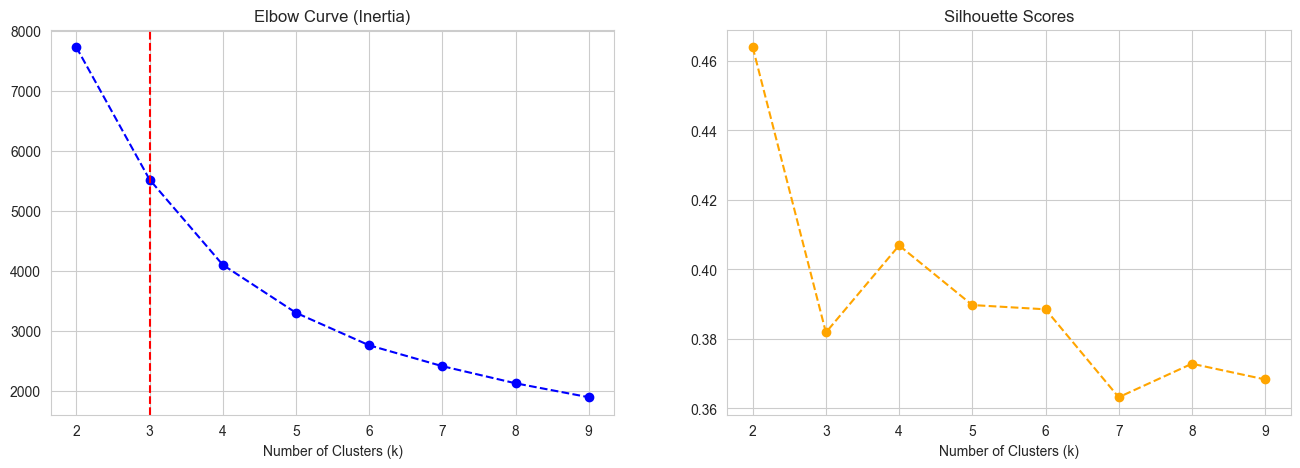

In [4]:
inertia = []
silhouette_avgs = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertia.append(km.inertia_)
    silhouette_avgs.append(silhouette_score(X_pca, labels))

# Plotting the Results
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Elbow Curve
ax[0].plot(k_range, inertia, marker='o', linestyle='--', color='b')
ax[0].set_title('Elbow Curve (Inertia)')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].axvline(x=3, color='r', linestyle='--') # Mark the elbow

# Silhouette Score
ax[1].plot(k_range, silhouette_avgs, marker='o', linestyle='--', color='orange')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')

save_plot('clustering_optimization.png', folder='clustering')
plt.show()

## 3. Final Model Execution (K=3)
Based on the elbow at 3 and the high silhouette score, we proceed with 3 clusters.

In [5]:
# Fit K-Means
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)

# Fit DBSCAN (Density-based comparison)
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

# Save results for the next notebook
results = pd.DataFrame({
    'KMeans': km_labels,
    'DBSCAN': db_labels
}, index=X.index)

results.to_csv('../data/processed/cluster_results.csv')
print("Clustering labels saved successfully.")

Clustering labels saved successfully.


## 4. t-SNE Visualization using k-means clustering
Finally, we project the high-dimensional data into 2D to see how well our 
3 clusters are separated.

Plot saved: ..\plots\clustering\tsne_final_k3.png


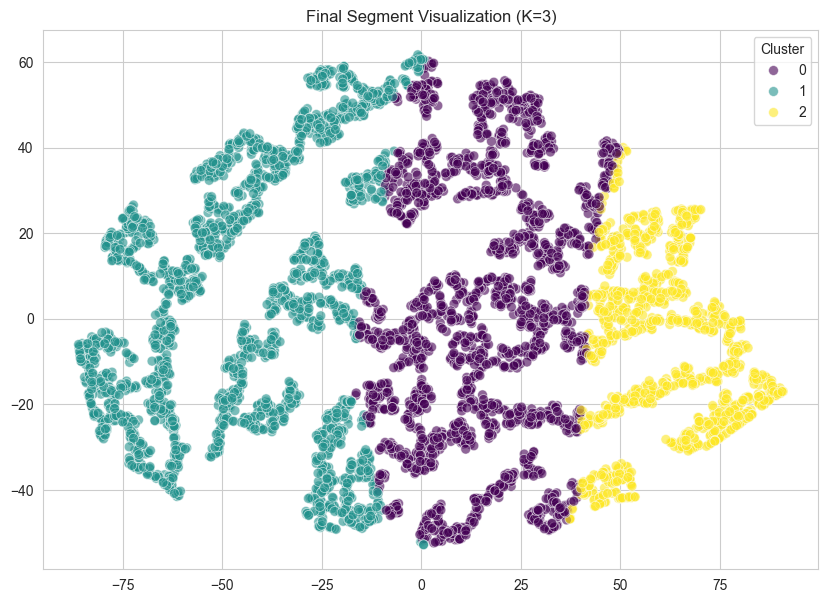

In [6]:
# Projecting PCA data into 2D t-SNE
tsne = TSNE(n_components=2, perplexity=35, random_state=42)
tsne_results = tsne.fit_transform(X_pca)

# Create Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1], 
    hue=km_labels, palette='viridis', 
    s=50, alpha=0.6, edgecolor='w'
)

plt.title(f'Final Segment Visualization (K={best_k})')
plt.legend(title='Cluster', loc='upper right')

save_plot('tsne_final_k3.png', folder='clustering')
plt.show()

## 5. Model Performance Metrics
To validate our choice of $K=3$, we examine the final Inertia (total within-cluster sum of squares) 
and the Silhouette Score, which measures how similar an object is to its own cluster 
compared to other clusters.

In [7]:
# 1. Final Inertia
print(f"Final K-Means Inertia: {kmeans.inertia_:.2f}")

# 2. Silhouette Score
# Higher is better (-1 to 1 range)
score = silhouette_score(X_pca, km_labels)
print(f"Final Silhouette Score: {score:.4f}")

# 3. Sample of Cluster Assignments
# Let's see the first 10 customers and their assigned groups
assignment_sample = pd.DataFrame({
    'Customer ID': X.index,
    'Assigned_Cluster': km_labels
}).head(10)

print("\nSample Cluster Assignments:")
display(assignment_sample)

Final K-Means Inertia: 5525.60
Final Silhouette Score: 0.3819

Sample Cluster Assignments:


,Customer ID,Assigned_Cluster
0,12346.0,2
1,12347.0,2
2,12348.0,0
3,12349.0,0
4,12350.0,1
5,12351.0,1
6,12352.0,2
7,12353.0,1
8,12354.0,1
9,12355.0,1


## 6. Analyzing Cluster Centroids
The centroids represent the "average" customer profile within each cluster in the PCA space.

Cluster Centroids (PCA Space):


,PC1,PC2
0,0.309647,-0.128947
1,-1.399942,0.089674
2,2.312536,0.066901


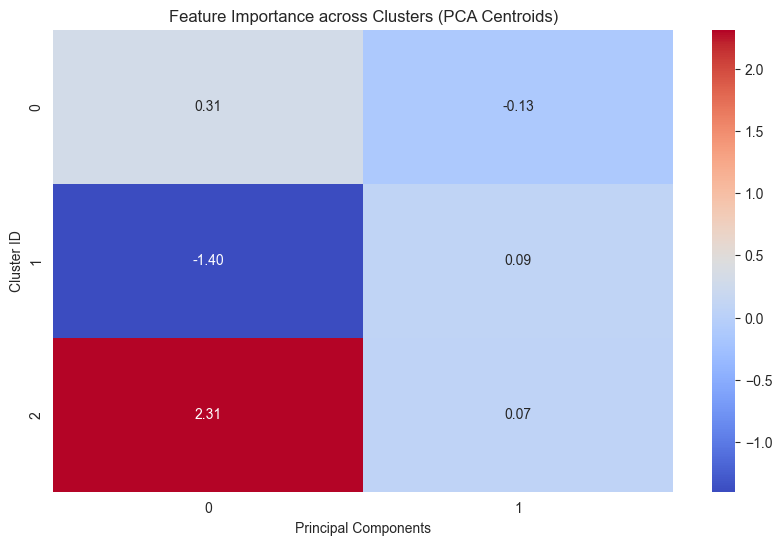

In [8]:
# Get the coordinates of the centers in the PCA space
centroids = kmeans.cluster_centers_

print("Cluster Centroids (PCA Space):")
display(pd.DataFrame(centroids, columns=[f'PC{i+1}' for i in range(centroids.shape[1])]))

# Visualizing where these centers sit
plt.figure(figsize=(10, 6))
sns.heatmap(centroids, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Importance across Clusters (PCA Centroids)')
plt.xlabel('Principal Components')
plt.ylabel('Cluster ID')
plt.show()

## 7. Segment Distribution
Finally, we check the volume of customers in each cluster to ensure the segments are balanced enough for targeted marketing.

Cluster Population Breakdown:


,Count,Percentage
0,2289,38.94
1,2427,41.29
2,1162,19.77


C:\Users\Aynorix\AppData\Local\Temp\ipykernel_21180\385490845.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_df.index, y='Count', data=dist_df, palette='viridis')


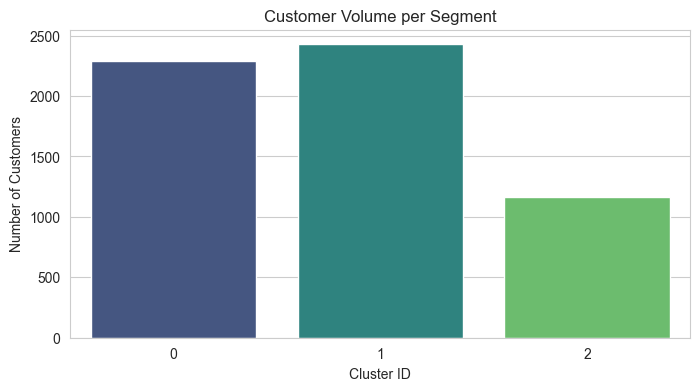

In [9]:
# Count customers in each group
counts = pd.Series(km_labels).value_counts().sort_index()
dist_df = pd.DataFrame({
    'Count': counts,
    'Percentage': (counts / len(km_labels) * 100).round(2)
})

print("Cluster Population Breakdown:")
display(dist_df)

# Visual Bar Chart
plt.figure(figsize=(8, 4))
sns.barplot(x=dist_df.index, y='Count', data=dist_df, palette='viridis')
plt.title('Customer Volume per Segment')
plt.ylabel('Number of Customers')
plt.xlabel('Cluster ID')
plt.show()

## 4. Density-Based Spatial Clustering (DBSCAN)
Unlike K-Means, which is centroid-based, **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) identifies clusters based on the density of data points. 

### Key Characteristics:
* **Noise Detection**: It can identify outliers as "noise" (labeled as -1), which is useful for filtering extreme wholesale accounts or unusual retail behavior.
* **No Predefined K**: It does not require us to specify the number of clusters in advance.
* **Shape Flexibility**: It can find clusters of arbitrary shapes, not just spherical ones.

In our implementation, we used DBSCAN primarily as a diagnostic tool to verify the density of our customer segments and identify true outliers.

Estimated number of DBSCAN clusters: 1
Estimated number of noise points: 63 (out of 5878)
Plot saved: ..\plots\clustering\dbscan_comparison.png


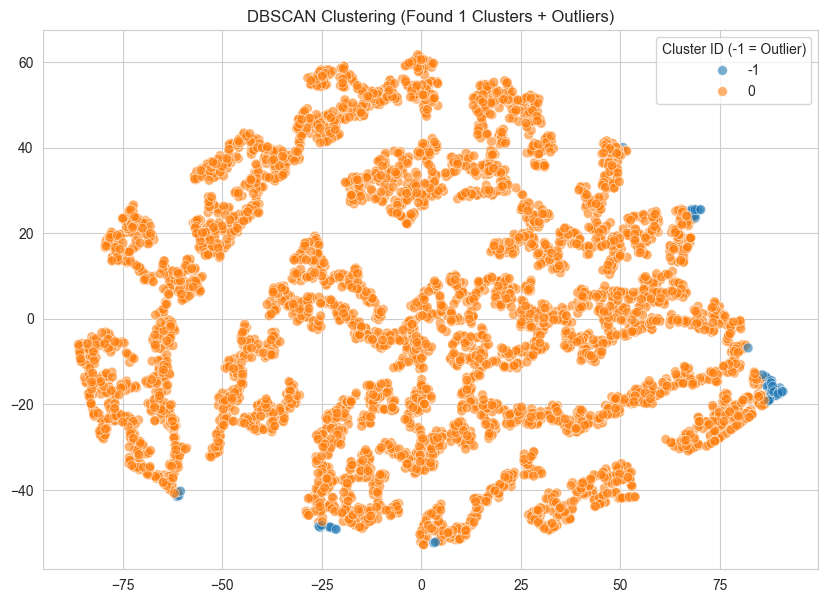

In [17]:
# 1. Initialize DBSCAN
# eps: The distance to search for neighbors
# min_samples: Minimum points to form a 'dense' region
dbscan = DBSCAN(eps=0.35, min_samples=12)

# 2. Fit and Predict
db_labels = dbscan.fit_predict(X_pca)

# 3. Analyze Results
# DBSCAN labels outliers as -1
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)

print(f"Estimated number of DBSCAN clusters: {n_clusters_db}")
print(f"Estimated number of noise points: {n_noise_db} (out of {len(X_pca)})")

# 4. Visualization (t-SNE)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1], 
    hue=db_labels, palette='tab10', 
    s=50, alpha=0.6, edgecolor='w'
)

plt.title(f'DBSCAN Clustering (Found {n_clusters_db} Clusters + Outliers)')
plt.legend(title='Cluster ID (-1 = Outlier)', loc='upper right')
save_plot('dbscan_comparison.png', folder='clustering')
plt.show()

## 5. Hierarchical (Agglomerative) Clustering
Hierarchical clustering builds a "tree" of clusters (a **Dendrogram**) to represent the multi-level relationships between customers.

### The Dendrogram Analysis:
* **Connectivity-Based**: This approach starts with each point as its own cluster and merges the closest pairs iteratively.
* **Mathematical Validation**: By drawing a horizontal line across the dendrogram (the "cut"), we can mathematically verify the optimal number of clusters.
* **Linkage Method**: We used the **Ward** linkage method, which minimizes the total within-cluster variance, resulting in compact and well-separated segments.

This method provides a "bottom-up" perspective that confirms whether the 3 segments identified by K-Means are naturally occurring hierarchies in the data.

Plot saved: ..\plots\clustering\dendrogram.png


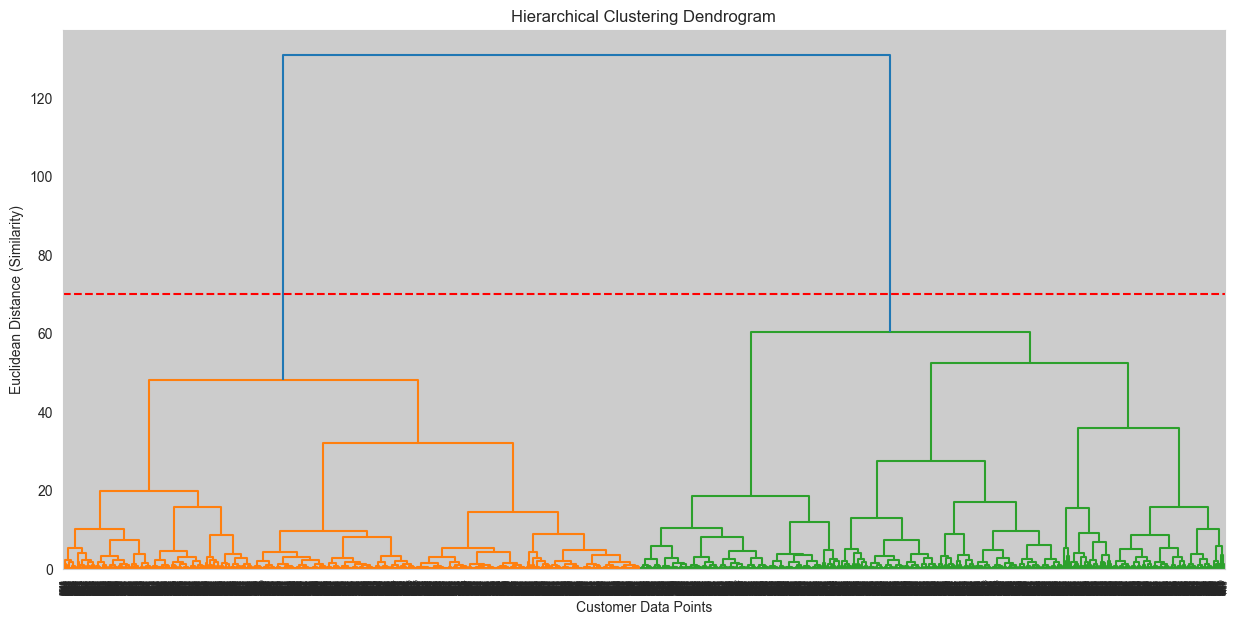

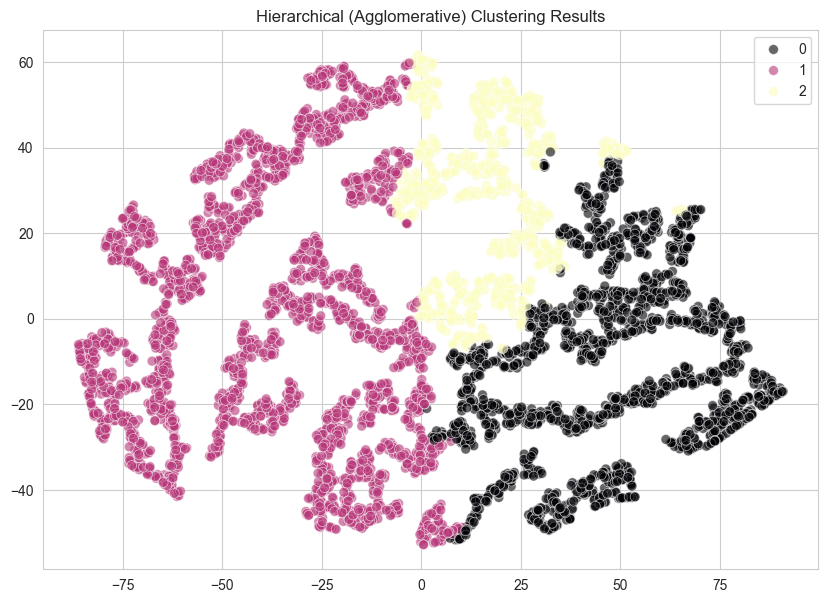

Hierarchical Clustering completed. Value counts:
1    2924
0    1942
2    1012
Name: count, dtype: int64


In [22]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# 1. Create the Dendrogram (The 'Tree' Visualization)
plt.figure(figsize=(15, 7))
# Linkage 'ward' minimizes the variance of clusters being merged
linkage_matrix = sch.linkage(X_pca, method='ward')
dendrogram = sch.dendrogram(linkage_matrix)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Customer Data Points')
plt.ylabel('Euclidean Distance (Similarity)')
# Draw a horizontal line to show where the 'cut' happens for 3 clusters
plt.axhline(y=70, color='r', linestyle='--') 
save_plot('dendrogram.png', folder='clustering')
plt.show()

# 2. Fit the Agglomerative Model
# We use 3 clusters to remain consistent with our K-Means findings
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_pca)

# 3. Visualize Hierarchical Results via t-SNE for Comparison
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1], 
    hue=hc_labels, palette='magma', 
    s=50, alpha=0.6, edgecolor='w'
)

plt.title('Hierarchical (Agglomerative) Clustering Results')
plt.show()

print(f"Hierarchical Clustering completed. Value counts:\n{pd.Series(hc_labels).value_counts()}")

In [21]:
results = pd.DataFrame({
    'KMeans': km_labels,
    'DBSCAN': db_labels,
    'Hierarchical': hc_labels  # Add this line
}, index=X.index)

results.to_csv('../data/processed/cluster_results.csv')
print("All clustering labels saved successfully.")

All clustering labels saved successfully.
